In [9]:
import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

### Spatial Transcriptomics example

In [10]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

In [11]:

sc.pp.highly_variable_genes(adata, n_top_genes=2000)

#we need the raw counts
adata.X = adata.raw.X

adata = adata[:, adata.var['highly_variable']]

In [5]:
adata.n_vars

2000

In [12]:
#This needs to be run to setup the model. Pass a adata (or mudata), and pass the key of the obsp containing
#the connectivity graph

adata.uns.pop("_spatial_graph", None)
adata.uns.pop("_spatial_graphs", None)
MultimodalAmortizedLDA.setup_anndata(adata, spatial_key="connectivities")

/data/nelkazwi/code/omics-topic/src/omics_topic/models/amortizedLDA.py:288: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["_spatial_graph"] = spatial_info


In [13]:
model = MultimodalAmortizedLDA(
    adata,
    n_inputs_modalities=[adata.n_vars],
    #specify the likelihoods (here 1 modality only). Can be multinomial or gamma_poisson
    likelihoods=["gamma_poisson"],
    n_topics=30,
    n_hidden=64, #hidden layer size in the encoder
   
)

#These flags should all be true and show that the model is supporting the spatial graph
print("spatial flag:", model.spatial)                             
print("use_gcn:", model.module.guide.use_gcn)                     
#print("adjacency set:", model.module.guide.adjacency is not None) 
print("gcn encoders:", model.module.guide.gcn_encoders is not None)


spatial flag: True
use_gcn: True
gcn encoders: True


In [14]:
# model.train() is inherited from PyroSVIMixin from scvi-tools. Here are all the options: 
# https://github.com/scverse/scvi-tools/blob/main/src/scvi/model/base/_pyromixin.py#L95
model.train(
    max_epochs=200,
    batch_size=128,  # full batch
    train_size=1.0,          # use all cells
    validation_size=0,       # no val subset
    log_every_n_steps=1,     # optional
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/nelkazwi/omics/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 1/200:   0%|          | 0/200 [00:00<?, ?it/s]

/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 2/200:   0%|          | 1/200 [00:00<01:28,  2.25it/s, v_num=1]

/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


...

Epoch 200/200: 100%|█████████▉| 199/200 [01:04<00:00,  3.20it/s, v_num=1, elbo_train=8.17e+6]

/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/nelkazwi/omics/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 200/200: 100%|██████████| 200/200 [01:04<00:00,  3.19it/s, v_num=1, elbo_train=8.19e+6]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [01:04<00:00,  3.10it/s, v_num=1, elbo_train=8.19e+6]


In [21]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

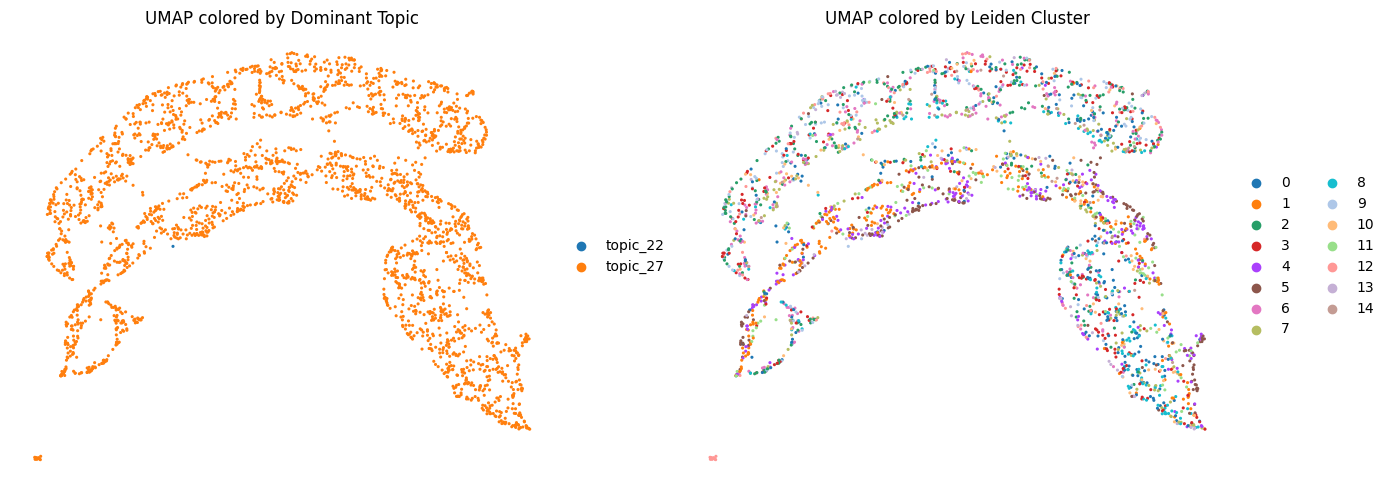

In [17]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 1) Get topic proportions per cell
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values

# 2) Compute UMAP on topic space
sc.pp.neighbors(adata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(adata, min_dist=0.3)

# 3) Get dominant topic per cell
adata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Color by dominant topic
sc.pl.umap(
    adata, 
    color="dominant_topic", 
    ax=axes[0],
    frameon=False, 
    s=20,
    title="UMAP colored by Dominant Topic",
    show=False
)

# Right: Color by leiden (if available) or any other annotation
if "leiden" in adata.obs.columns:
    sc.pl.umap(
        adata,
        color="leiden",
        ax=axes[1],
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False
    )
else:
    # Compute leiden if not present
    sc.tl.leiden(adata, resolution=0.5)
    sc.pl.umap(
        adata,
        color="leiden",
        ax=axes[1],
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False
    )

plt.tight_layout()
plt.show()

In [18]:
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)

In [19]:
theta

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,...,topic_20,topic_21,topic_22,topic_23,topic_24,topic_25,topic_26,topic_27,topic_28,topic_29
AAACAAGTATCTCCCA-1,0.000028,0.105291,0.000033,0.048386,0.000048,0.000032,0.000050,0.127333,0.000068,0.000029,...,0.000039,0.000017,0.218415,0.092225,0.000040,0.000020,0.000028,0.248561,0.000034,0.020482
AAACAATCTACTAGCA-1,0.000078,0.107113,0.000080,0.054613,0.000074,0.000058,0.000096,0.126940,0.000126,0.000072,...,0.000065,0.000042,0.203645,0.096269,0.000065,0.000043,0.000057,0.231713,0.000085,0.026112
AAACACCAATAACTGC-1,0.000011,0.099732,0.000020,0.043564,0.000014,0.000018,0.000033,0.132394,0.000050,0.000078,...,0.000023,0.000011,0.229470,0.088316,0.000016,0.000017,0.000019,0.259908,0.000020,0.016071
AAACAGAGCGACTCCT-1,0.000023,0.104697,0.000036,0.047036,0.000028,0.000025,0.000043,0.127688,0.000063,0.000037,...,0.000039,0.000018,0.221470,0.091109,0.000029,0.000019,0.000024,0.251244,0.000057,0.019750
AAACCGGGTAGGTACC-1,0.000027,0.103137,0.000027,0.046898,0.000024,0.000029,0.000031,0.129764,0.000065,0.000033,...,0.000033,0.000015,0.223787,0.090502,0.000023,0.000030,0.000026,0.253194,0.000029,0.017971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0.000026,0.103429,0.000043,0.049776,0.000034,0.000050,0.000054,0.137526,0.000140,0.000063,...,0.000051,0.000036,0.215203,0.093264,0.000036,0.000043,0.000039,0.236871,0.000037,0.021336
TTGTTTCACATCCAGG-1,0.000016,0.100800,0.000026,0.045578,0.000027,0.000029,0.000043,0.132580,0.000067,0.000042,...,0.000026,0.000014,0.224834,0.089824,0.000020,0.000023,0.000022,0.254449,0.000025,0.017486
TTGTTTCATTAGTCTA-1,0.000038,0.102578,0.000057,0.050426,0.000045,0.000040,0.000079,0.130893,0.000121,0.000047,...,0.000049,0.000034,0.214791,0.092957,0.000037,0.000035,0.000043,0.243913,0.000041,0.022084
TTGTTTCCATACAACT-1,0.000021,0.104238,0.000032,0.047352,0.000029,0.000024,0.000038,0.128454,0.000050,0.000031,...,0.000030,0.000013,0.222352,0.090648,0.000027,0.000018,0.000029,0.252150,0.000042,0.019150


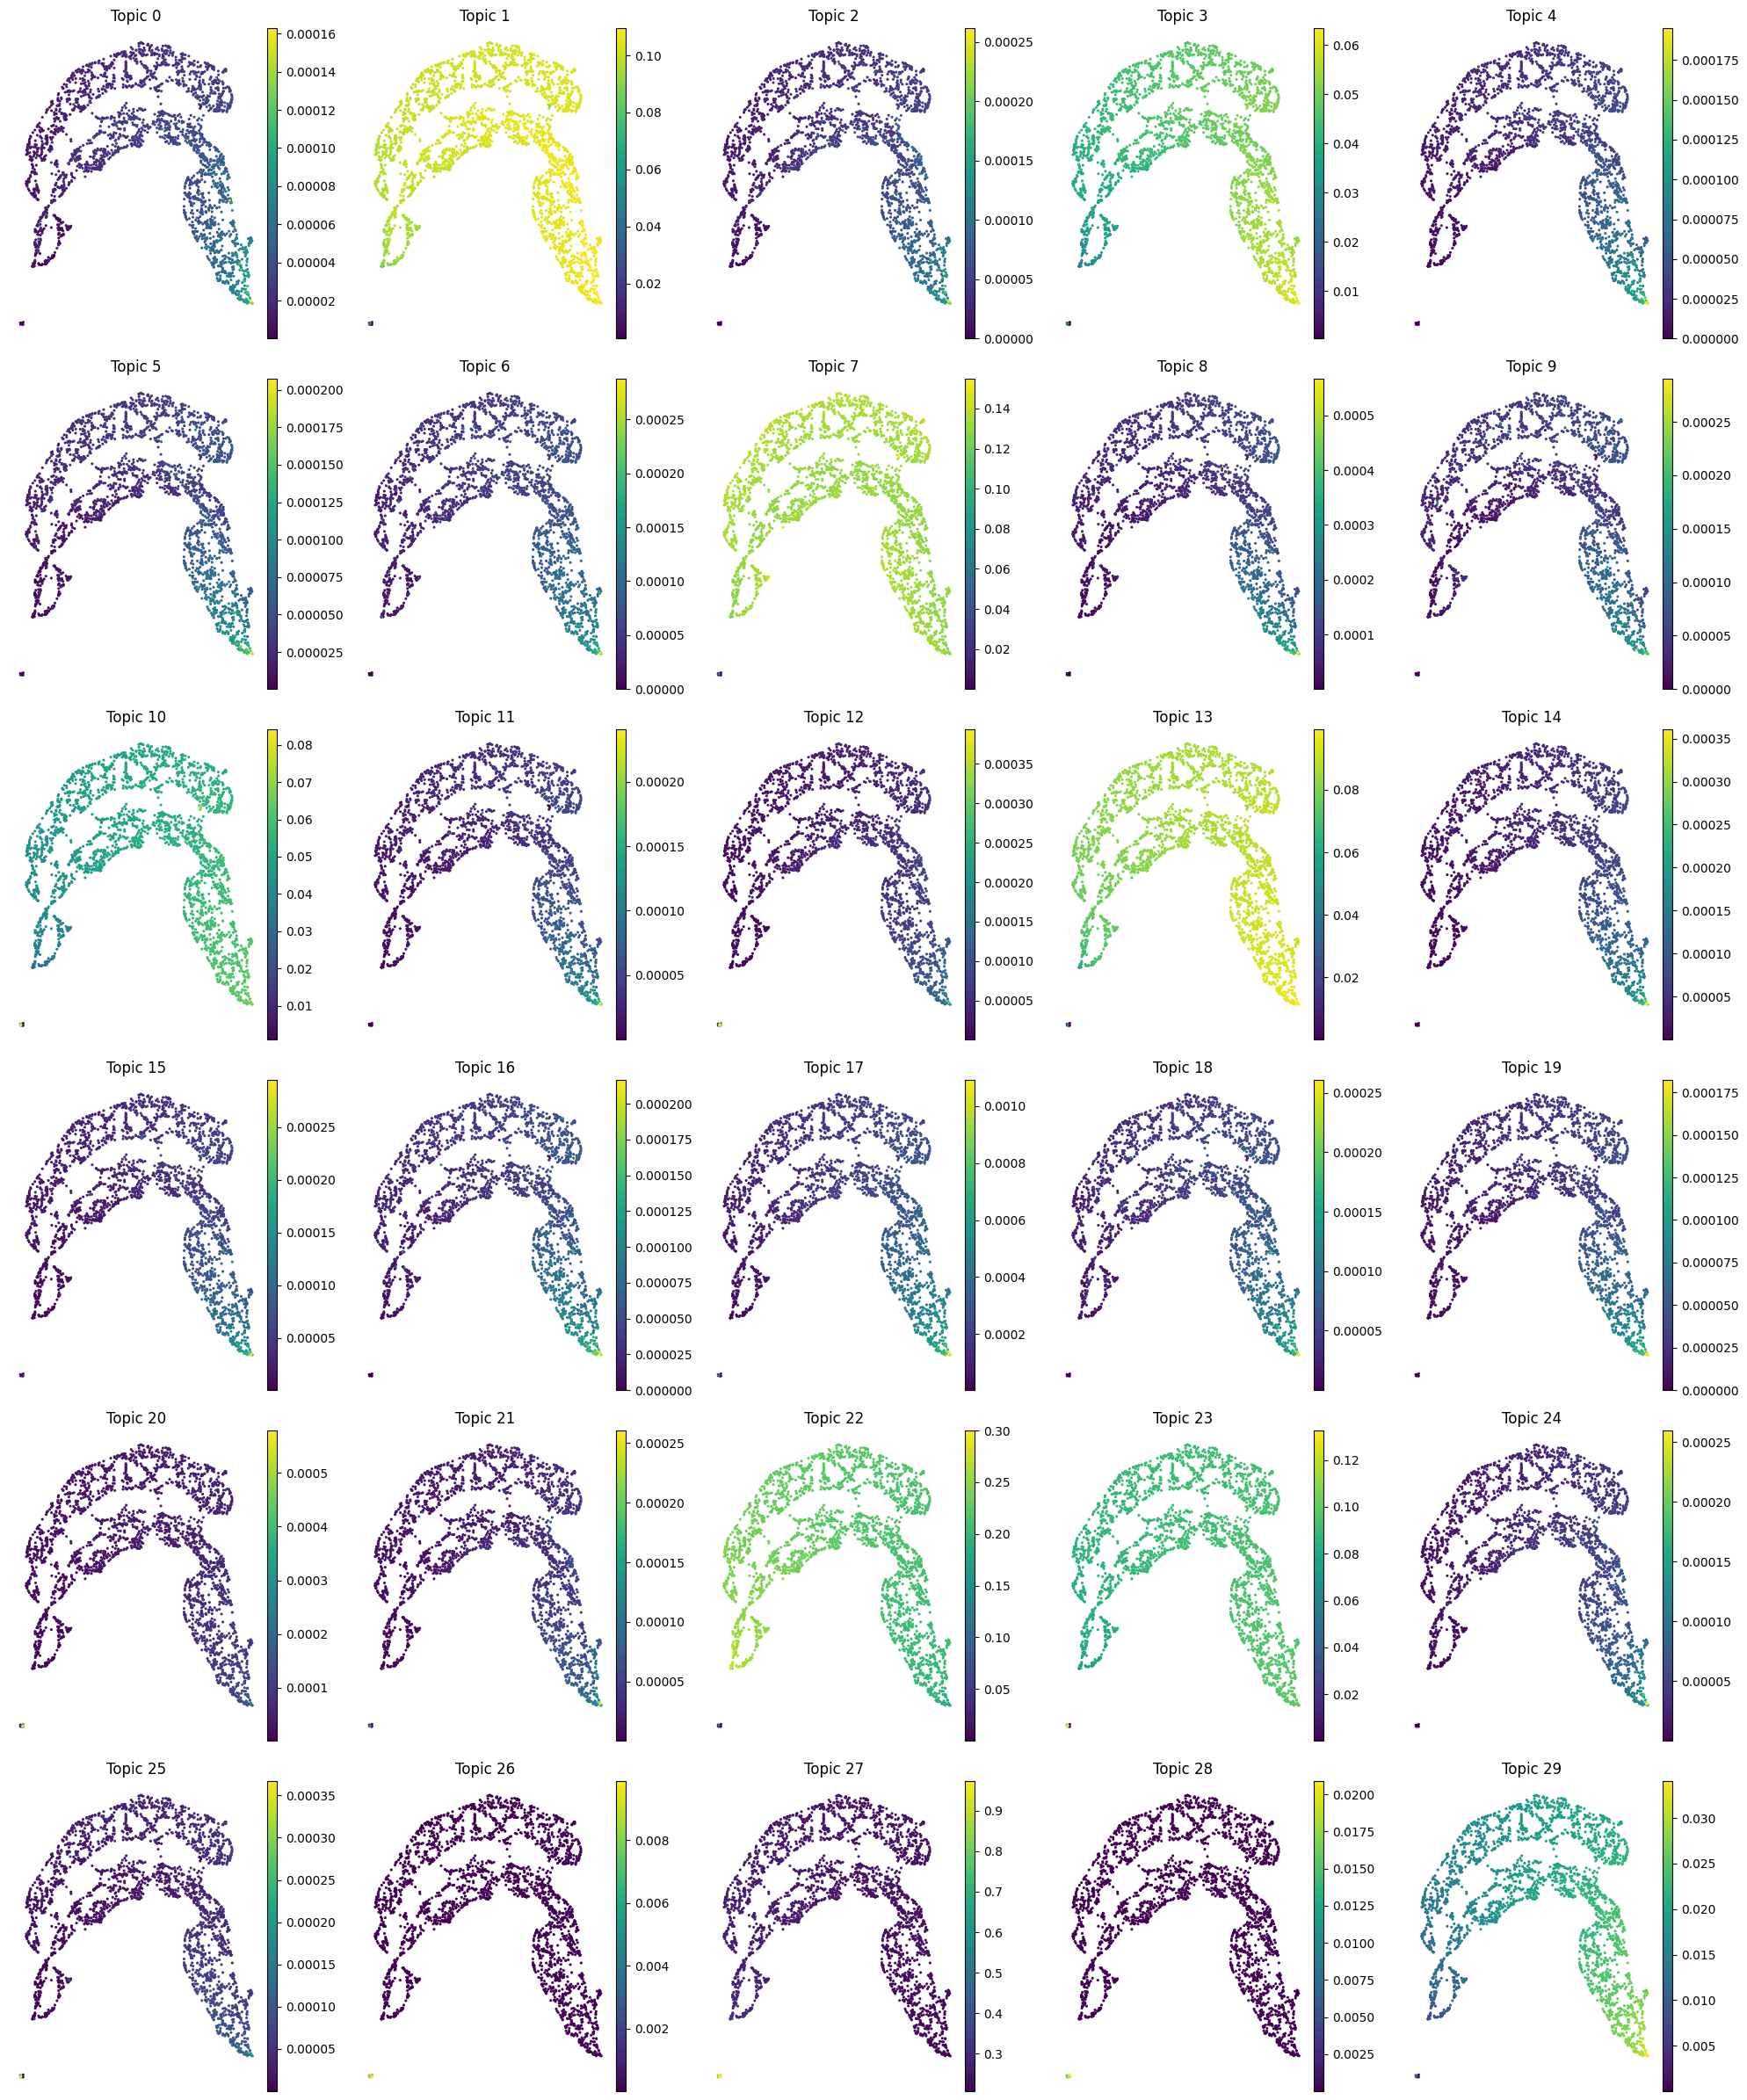

In [20]:
import math
T = 30   # number of topics you want to plot

ncols = 5                            # choose layout
nrows = math.ceil(T / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))

axes = axes.flatten()

for i in range(T):
    ax = axes[i]

    # assign topic i values to adata.obs
    adata.obs["topic"] = theta.iloc[:, i].values

    sc.pl.umap(
        adata,
        color="topic",
        frameon=False,
        s=20,
        ax=ax,
        show=False,
        title=f"Topic {i}"
    )

# Remove empty subplot frames if T < nrows*ncols
for j in range(T, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

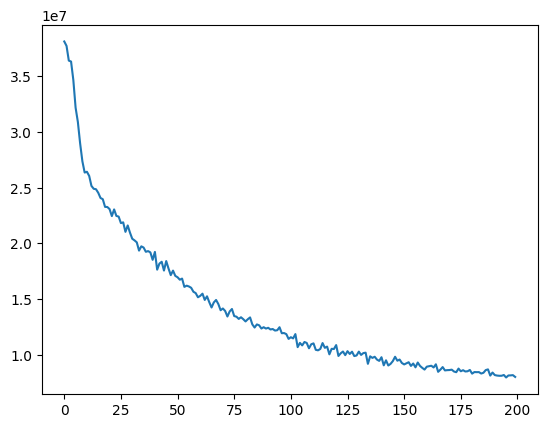

In [21]:
plt.plot(model.history['elbo_train'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'topic_14'),
  Text(1, 0, 'topic_13'),
  Text(2, 0, 'topic_18'),
  Text(3, 0, 'topic_19'),
  Text(4, 0, 'topic_2'),
  Text(5, 0, 'topic_28'),
  Text(6, 0, 'topic_22'),
  Text(7, 0, 'topic_1'),
  Text(8, 0, 'topic_29'),
  Text(9, 0, 'topic_16')])

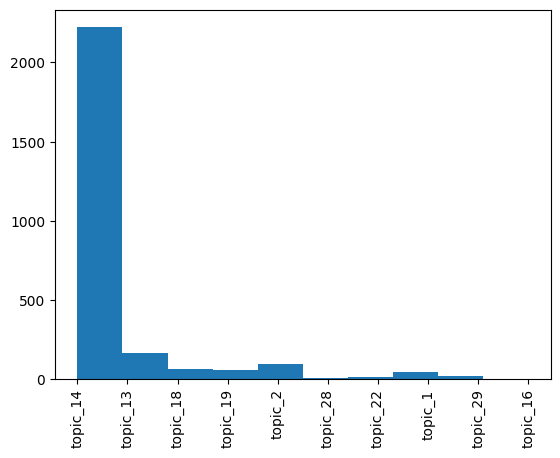

In [13]:
plt.hist(adata.obs["dominant_topic"])
plt.xticks(rotation=90)

In [22]:
topic_prop = theta

for i in topic_prop.columns:
    adata.obs[i] = topic_prop[i]

In [23]:
from omics_topic import pl



In [25]:
topic_prop.columns

Index(['topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5',
       'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11',
       'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17',
       'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23',
       'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29'],
      dtype='object')

In [24]:
pl.spatial(adata, color=topic_prop.columns, ncols=5, size=40, vmax="p99")

AttributeError: module 'omics_topic.pl' has no attribute 'spatial'